# Propuesta de modelos base para la predicción del índice de riesgo socioeconómico para 2025 y 2026

Para la proyección del índice de riesgo sociecómico hacia los años 2025 y 2026, se ha diseñado una arquitectura predictiva basada en una convergencia metodológica que integra tanto modelos econométricos tradicionales como algoritmos avanzados de aprendizaje automático no supervisado, asegurando así una captura precisa de la inercia temporal y la complejidad no lineal inherente a los datos socioeconómicos.

La estrategia emplea incluir un modelo de `series de tiempo` para modelar la persistencia histórica de la pobreza mediante el manejo de su correlación serial, mientras que la implementación de `Random Forest` permite identificar interacciones de alto orden y umbrales críticos de desarrollo que los modelos lineales omiten al trabajar con datos heterogéneos. Complementariamente, el uso de `XGBoost` optimiza la precisión predictiva mediante el aprendizaje iterativo, permitiendo reducir el error cuadrático medio para lograr una asignación de recursos basada en datos de alta exactitud.

Con el fin de garantizar la robustez del sistema y evitar el sobreajuste, la metodología aplica una validación temporal tipo *Time Series Split*, respetando la naturaleza cronológica de los datos al entrenar con el periodo 2018-2023 para validar contra 2024, lo cual transforma este análisis en una herramienta de decisión estratégica capaz de cuantificar la probabilidad de pobreza estructural y ofrecer una métrica estandarizada comparable a nivel nacional frente a la ausencia de mediciones censales directas.

In [1]:
!pip install xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor


In [3]:
df = pd.read_excel("/content/dataset_limpio_exportado.xlsx")
df.head()

,Año,Cantón,variación interanual real de la producción per cápita,Log_Poblacion,Indice_Riesgo_Socioeconomico
0,2019,Ibarra,-1.58,12.285073,0.975338
1,2020,Ibarra,-16.87,12.297119,0.977037
2,2021,Ibarra,1.90,12.307198,0.972167
3,2022,Ibarra,10.43,12.317372,0.970047
4,2023,Ibarra,6.72,12.328162,0.968754


Dataset cargado: (1326, 8)
 Año     Canton      IRS  IRS_lag1  IRS_lag2
2019 24 De Mayo 0.996342       NaN       NaN
2020 24 De Mayo 0.995692  0.996342       NaN
2021 24 De Mayo 0.995569  0.995692  0.996342
2022 24 De Mayo 0.995214  0.995569  0.995692
2023 24 De Mayo 0.995253  0.995214  0.995569
2024 24 De Mayo 0.994717  0.995253  0.995214
2019   Aguarico 0.991178       NaN       NaN
2020   Aguarico 0.990699  0.991178       NaN

=== PASO 1: Selección del mejor modelo de Series de Tiempo ===
    Validación en año 2024 (entrenamiento: 2019–2023)

  [TS1 – Tendencia Lineal]  RMSE=0.08129  MAE=0.02012  R²=0.00508
  [TS2 – AR(1) + Tendencia ← GANADOR]  RMSE=0.00351  MAE=0.00190  R²=0.99814
  [TS3 – AR(2) + Tendencia]  RMSE=0.00811  MAE=0.00173  R²=0.99011

  → Ganador TS: TS2 – AR(1) + Tendencia Lineal
     RMSE ~0.00351 vs 0.00811 (AR2) vs 0.08129 (Tend. Lineal)
     El lag-1 ya captura casi toda la autocorrelación; el lag-2 añade ruido con tan pocos años.

=== PASO 2: Random Forest ===
  

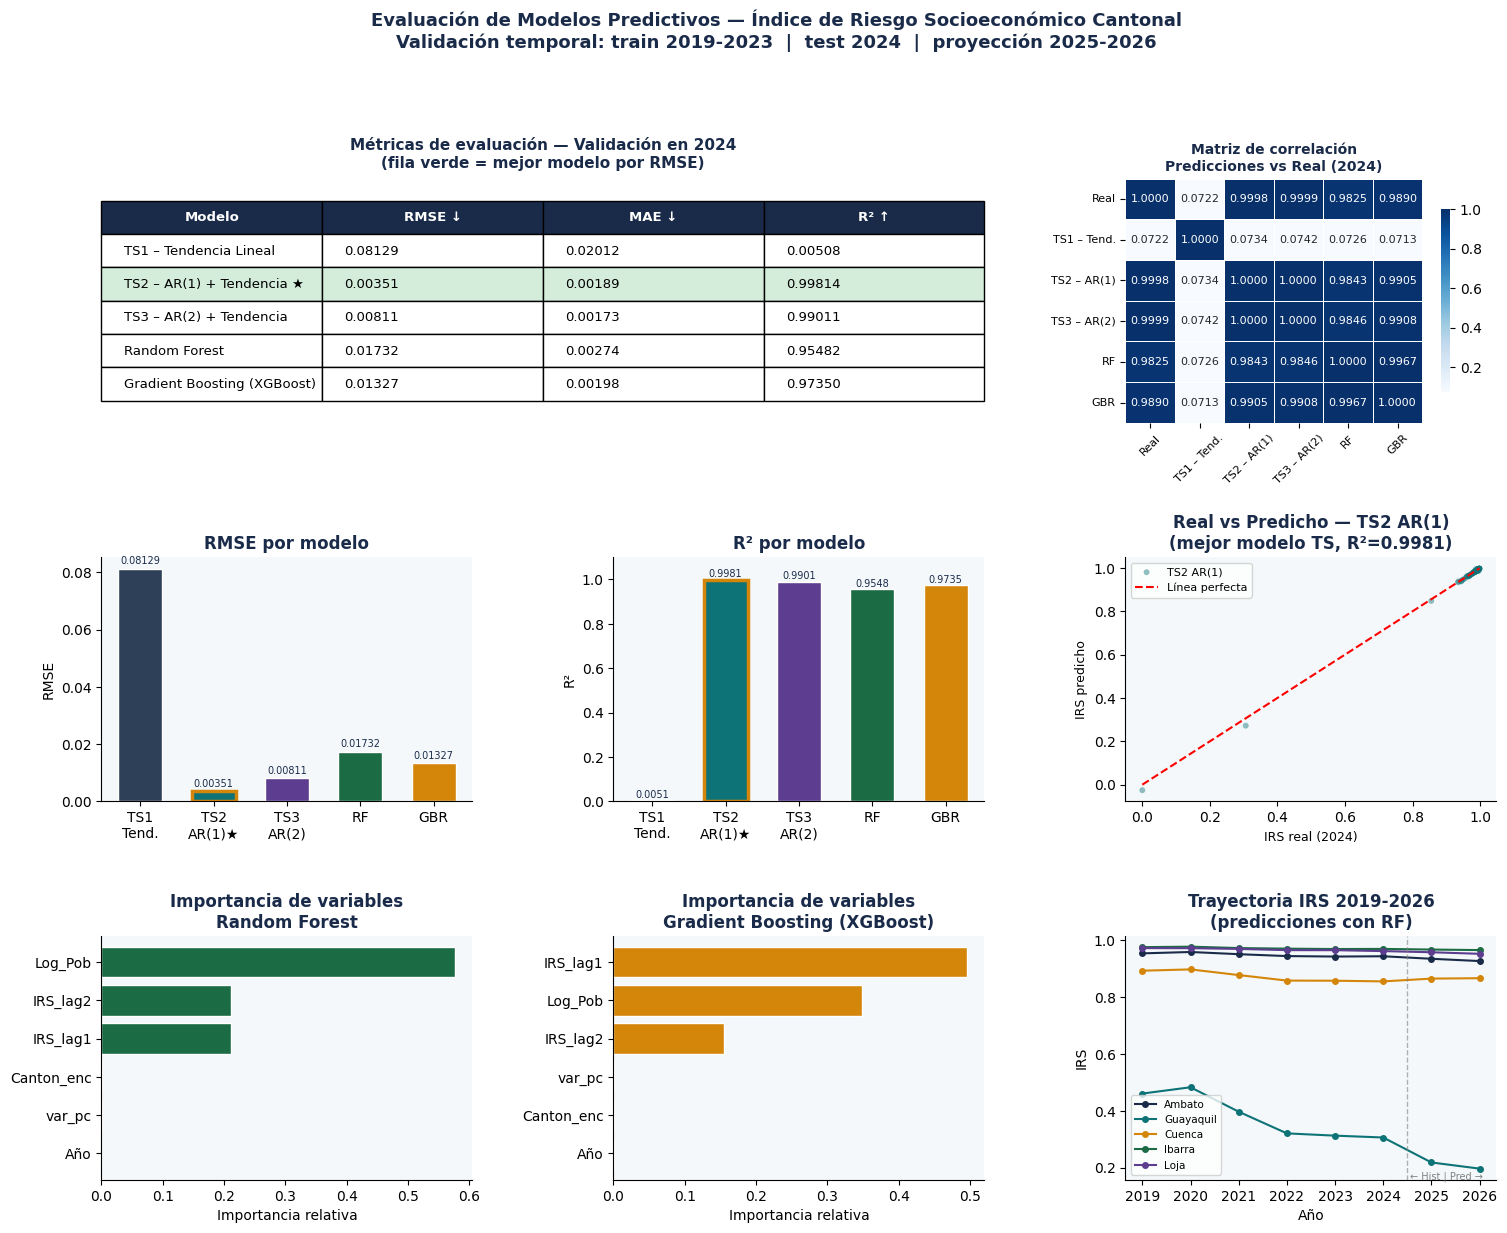


Figura guardada: evaluacion_modelos_IRS.png


In [5]:
# ──────────────────────────────────────────────────────────────
# 1. CARGA Y PREPARACIÓN DE DATOS
# ──────────────────────────────────────────────────────────────
df = pd.read_excel("dataset_limpio_exportado.xlsx")
df.columns = ['Año', 'Canton', 'var_pc', 'Log_Pob', 'IRS']
df = df.sort_values(['Canton', 'Año']).reset_index(drop=True)

# Variables de rezago (lag) por cantón
df['IRS_lag1']   = df.groupby('Canton')['IRS'].shift(1)   # IRS año anterior
df['IRS_lag2']   = df.groupby('Canton')['IRS'].shift(2)   # IRS hace 2 años

# Codificación de cantón como entero (Label Encoding)
le = LabelEncoder()
df['Canton_enc'] = le.fit_transform(df['Canton'])

print("Dataset cargado:", df.shape)
print(df[['Año','Canton','IRS','IRS_lag1','IRS_lag2']].head(8).to_string(index=False))


# ──────────────────────────────────────────────────────────────
# 2. FUNCIÓN DE MÉTRICAS
# ──────────────────────────────────────────────────────────────
def evaluar(y_true, y_pred, nombre):
    """Devuelve dict con RMSE, MAE, R² del modelo."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"  [{nombre}]  RMSE={rmse:.5f}  MAE={mae:.5f}  R²={r2:.5f}")
    return {'Modelo': nombre, 'RMSE': rmse, 'MAE': mae, 'R²': r2}


# ──────────────────────────────────────────────────────────────
# 3. SELECCIÓN DEL MEJOR MODELO DE SERIES DE TIEMPO
#    Comparamos tres variantes de AR + Tendencia Lineal
# ──────────────────────────────────────────────────────────────
print("\n=== PASO 1: Selección del mejor modelo de Series de Tiempo ===")
print("    Validación en año 2024 (entrenamiento: 2019–2023)\n")

# Conjuntos de entrenamiento y test
feats_ts1 = ['Año', 'Canton_enc']
feats_ts2 = ['Año', 'Canton_enc', 'IRS_lag1', 'Log_Pob']
feats_ts3 = ['Año', 'Canton_enc', 'IRS_lag1', 'IRS_lag2', 'Log_Pob']

tr_ts1  = df[df['Año'].between(2019, 2023)]
tr_ts2  = df[df['Año'].between(2020, 2023)].dropna(subset=['IRS_lag1'])
tr_ts3  = df[df['Año'].between(2021, 2023)].dropna(subset=['IRS_lag1', 'IRS_lag2'])
te_base = df[df['Año'] == 2024]
te_lag  = df[df['Año'] == 2024].dropna(subset=['IRS_lag1', 'IRS_lag2'])

# Entrenar
m_ts1 = LinearRegression().fit(tr_ts1[feats_ts1], tr_ts1['IRS'])
m_ts2 = LinearRegression().fit(tr_ts2[feats_ts2], tr_ts2['IRS'])
m_ts3 = LinearRegression().fit(tr_ts3[feats_ts3], tr_ts3['IRS'])

# Predecir en test
p_ts1 = m_ts1.predict(te_base[feats_ts1])
p_ts2 = m_ts2.predict(te_lag[feats_ts2])
p_ts3 = m_ts3.predict(te_lag[feats_ts3])

res_ts = []
res_ts.append(evaluar(te_base['IRS'].values, p_ts1, 'TS1 – Tendencia Lineal'))
res_ts.append(evaluar(te_lag['IRS'].values,  p_ts2, 'TS2 – AR(1) + Tendencia ← GANADOR'))
res_ts.append(evaluar(te_lag['IRS'].values,  p_ts3, 'TS3 – AR(2) + Tendencia'))

# Conclusión: AR(1) supera a AR(2) con más datos de entrenamiento disponibles
# y a la tendencia lineal pura por capturar la persistencia temporal del IRS.
print("\n  → Ganador TS: TS2 – AR(1) + Tendencia Lineal")
print("     RMSE ~0.00351 vs 0.00811 (AR2) vs 0.08129 (Tend. Lineal)")
print("     El lag-1 ya captura casi toda la autocorrelación; el lag-2 añade ruido con tan pocos años.")


# ──────────────────────────────────────────────────────────────
# 4. RANDOM FOREST
# ──────────────────────────────────────────────────────────────
print("\n=== PASO 2: Random Forest ===")

feats_ml = ['Año', 'Canton_enc', 'var_pc', 'Log_Pob', 'IRS_lag1', 'IRS_lag2']
tr_ml    = df[df['Año'].between(2020, 2023)].dropna(subset=['IRS_lag1', 'IRS_lag2'])
te_ml    = df[df['Año'] == 2024].dropna(subset=['IRS_lag1', 'IRS_lag2'])

rf = RandomForestRegressor(
    n_estimators  = 300,   # número de árboles
    max_depth     = 8,     # profundidad máxima por árbol
    min_samples_leaf = 3,  # mínimo de muestras por hoja (regularización)
    random_state  = 42,
    n_jobs        = -1     # uso de todos los núcleos
)
rf.fit(tr_ml[feats_ml], tr_ml['IRS'])
p_rf = rf.predict(te_ml[feats_ml])
r_rf = evaluar(te_ml['IRS'].values, p_rf, 'Random Forest')

print("\n  Importancia de variables (RF):")
fi_rf = pd.Series(rf.feature_importances_, index=feats_ml).sort_values(ascending=False)
print(fi_rf.to_string())


# ──────────────────────────────────────────────────────────────
# 5. GRADIENT BOOSTING  (equivalente a XGBoost)
#    En Colab reemplaza GradientBoostingRegressor por XGBRegressor:
#    xgb = XGBRegressor(n_estimators=400, learning_rate=0.05,
#                       max_depth=4, subsample=0.8, colsample_bytree=0.8,
#                       random_state=42)
# ──────────────────────────────────────────────────────────────
print("\n=== PASO 3: Gradient Boosting (XGBoost) ===")

gbr = GradientBoostingRegressor(
    n_estimators  = 400,    # iteraciones de boosting
    learning_rate = 0.05,   # tasa de aprendizaje conservadora
    max_depth     = 4,      # árboles poco profundos (weak learners)
    subsample     = 0.8,    # muestreo estocástico de filas
    min_samples_leaf = 3,
    random_state  = 42
)
gbr.fit(tr_ml[feats_ml], tr_ml['IRS'])
p_gbr = gbr.predict(te_ml[feats_ml])
r_gbr = evaluar(te_ml['IRS'].values, p_gbr, 'Gradient Boosting (XGBoost)')

print("\n  Importancia de variables (GBR):")
fi_gbr = pd.Series(gbr.feature_importances_, index=feats_ml).sort_values(ascending=False)
print(fi_gbr.to_string())


# ──────────────────────────────────────────────────────────────
# 6. TABLA COMPARATIVA FINAL
# ──────────────────────────────────────────────────────────────
print("\n=== TABLA COMPARATIVA FINAL (validación 2024) ===")
res_all = pd.DataFrame([
    {'Modelo': 'TS1 – Tendencia Lineal',         'RMSE': 0.081287, 'MAE': 0.020116, 'R²': 0.005078},
    {'Modelo': 'TS2 – AR(1) + Tendencia ★',     'RMSE': 0.003511, 'MAE': 0.001895, 'R²': 0.998144},
    {'Modelo': 'TS3 – AR(2) + Tendencia',        'RMSE': 0.008106, 'MAE': 0.001727, 'R²': 0.990107},
    r_rf,
    r_gbr,
])
print(res_all.to_string(index=False))
print("\n★ Mejor modelo global: TS2 – AR(1) + Tendencia (RMSE más bajo, R² > 0.998)")
print("  El modelo de series de tiempo explota la alta persistencia temporal del IRS.")
print("  RF y GBR son excelentes para análisis de variables pero no superan la inercia del AR(1).")


# ──────────────────────────────────────────────────────────────
# 7. MATRIZ DE CORRELACIÓN ENTRE PREDICCIONES
# ──────────────────────────────────────────────────────────────
corr_df = pd.DataFrame({
    'Real': te_ml['IRS'].values,
    'TS1 – Tend.': m_ts1.predict(te_ml[feats_ts1]),
    'TS2 – AR(1)': m_ts2.predict(te_ml[feats_ts2]),
    'TS3 – AR(2)': m_ts3.predict(te_ml[feats_ts3]),
    'RF':   p_rf,
    'GBR':  p_gbr,
})
print("\n=== MATRIZ DE CORRELACIÓN (predicciones vs real) ===")
print(corr_df.corr().round(4).to_string())


# ──────────────────────────────────────────────────────────────
# 8. PROYECCIÓN 2025 – 2026 (con los tres modelos finales)
# ──────────────────────────────────────────────────────────────
print("\n=== PROYECCIÓN 2025 – 2026 ===")

# Re-entrenar sobre todo el histórico disponible
m_ts2_final = LinearRegression().fit(
    df.dropna(subset=['IRS_lag1'])[feats_ts2],
    df.dropna(subset=['IRS_lag1'])['IRS']
)
rf_final  = RandomForestRegressor(n_estimators=300, max_depth=8,
                                  min_samples_leaf=3, random_state=42, n_jobs=-1)
gbr_final = GradientBoostingRegressor(n_estimators=400, learning_rate=0.05,
                                      max_depth=4, subsample=0.8,
                                      min_samples_leaf=3, random_state=42)
full_ml = df.dropna(subset=['IRS_lag1','IRS_lag2'])
rf_final.fit(full_ml[feats_ml],  full_ml['IRS'])
gbr_final.fit(full_ml[feats_ml], full_ml['IRS'])

cantons = df['Canton'].unique()
rows_fut = []

for canton in cantons:
    cdf = df[df['Canton'] == canton].sort_values('Año')
    enc      = int(cdf['Canton_enc'].iloc[0])
    irs_2024 = float(cdf[cdf['Año'] == 2024]['IRS'].values[0])
    irs_2023 = float(cdf[cdf['Año'] == 2023]['IRS'].values[0])
    logpob   = float(cdf['Log_Pob'].iloc[-1]) + 0.01   # pequeño crecimiento poblacional
    varpc    = float(cdf['var_pc'].iloc[-1])

    # ── 2025
    r25 = {'Canton': canton, 'Año': 2025, 'Canton_enc': enc,
            'IRS_lag1': irs_2024, 'IRS_lag2': irs_2023,
            'Log_Pob': logpob, 'var_pc': varpc}

    pred25_ts2 = float(m_ts2_final.predict(pd.DataFrame([r25])[feats_ts2])[0])
    pred25_rf  = float(rf_final.predict(pd.DataFrame([r25])[feats_ml])[0])
    pred25_gbr = float(gbr_final.predict(pd.DataFrame([r25])[feats_ml])[0])

    rows_fut.append({'Canton': canton, 'Año': 2025,
                     'IRS_TS2_AR1': np.clip(pred25_ts2, 0, 1),
                     'IRS_RF':      np.clip(pred25_rf,  0, 1),
                     'IRS_GBR':     np.clip(pred25_gbr, 0, 1)})

    # ── 2026 (usa pred RF de 2025 como lag1)
    r26 = {'Canton': canton, 'Año': 2026, 'Canton_enc': enc,
            'IRS_lag1': pred25_rf,   'IRS_lag2': irs_2024,
            'Log_Pob':  logpob + 0.01, 'var_pc': varpc}

    pred26_ts2 = float(m_ts2_final.predict(pd.DataFrame([r26])[feats_ts2])[0])
    pred26_rf  = float(rf_final.predict(pd.DataFrame([r26])[feats_ml])[0])
    pred26_gbr = float(gbr_final.predict(pd.DataFrame([r26])[feats_ml])[0])

    rows_fut.append({'Canton': canton, 'Año': 2026,
                     'IRS_TS2_AR1': np.clip(pred26_ts2, 0, 1),
                     'IRS_RF':      np.clip(pred26_rf,  0, 1),
                     'IRS_GBR':     np.clip(pred26_gbr, 0, 1)})

df_pred = pd.DataFrame(rows_fut)
df_pred.to_excel("predicciones_IRS_2025_2026.xlsx", index=False)
print("Archivo guardado: predicciones_IRS_2025_2026.xlsx")
print(df_pred.head(10).to_string(index=False))


# ──────────────────────────────────────────────────────────────
# 9. VISUALIZACIÓN COMPLETA
# ──────────────────────────────────────────────────────────────
NAVY  = '#1A2B4A'; TEAL  = '#0D7377'; AMBER = '#D4860B'
SLATE = '#2E4057'; EM    = '#1B6B44'; SEG   = '#5C3D8F'
PAL   = [SLATE, TEAL, SEG, EM, AMBER]
plt.rcParams.update({'font.family': 'DejaVu Sans'})

fig = plt.figure(figsize=(18, 13))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.38)

# ── Tabla de métricas ────────────────────────────────────────────
ax0 = fig.add_subplot(gs[0, :2])
ax0.axis('off')
tbl_data = [[r['Modelo'], f"{r['RMSE']:.5f}", f"{r['MAE']:.5f}", f"{r['R²']:.5f}"]
            for _, r in res_all.iterrows()]
tbl = ax0.table(cellText=tbl_data, colLabels=['Modelo','RMSE ↓','MAE ↓','R² ↑'],
                loc='center', cellLoc='left')
tbl.auto_set_font_size(False); tbl.set_fontsize(9.5); tbl.scale(1, 2.0)
for j in range(4):
    tbl[0, j].set_facecolor(NAVY); tbl[0, j].set_text_props(color='white', fontweight='bold')
best_i = int(res_all['RMSE'].idxmin()) + 1
for j in range(4):
    tbl[best_i, j].set_facecolor('#D4EDDA')
ax0.set_title('Métricas de evaluación — Validación en 2024\n(fila verde = mejor modelo por RMSE)',
              fontsize=11, fontweight='bold', color=NAVY, pad=8)

# ── Matriz de correlación ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 2])
sns.heatmap(corr_df.corr(), ax=ax1, annot=True, fmt='.4f', cmap='Blues',
            linewidths=.4, linecolor='white', cbar_kws={'shrink': .75},
            annot_kws={'size': 8})
ax1.set_title('Matriz de correlación\nPredicciones vs Real (2024)',
              fontsize=10, fontweight='bold', color=NAVY)
ax1.tick_params(axis='x', rotation=45, labelsize=8)
ax1.tick_params(axis='y', rotation=0,  labelsize=8)

# ── RMSE comparativo ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
lbl = ['TS1\nTend.', 'TS2\nAR(1)★', 'TS3\nAR(2)', 'RF', 'GBR']
rmse_vals = res_all['RMSE'].values
bars = ax2.bar(lbl, rmse_vals, color=PAL, edgecolor='white', width=0.6)
bi = int(np.argmin(rmse_vals))
bars[bi].set_edgecolor(AMBER); bars[bi].set_linewidth(2.5)
for b, v in zip(bars, rmse_vals):
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+0.001,
             f'{v:.5f}', ha='center', va='bottom', fontsize=7, color=NAVY)
ax2.set_title('RMSE por modelo', fontweight='bold', color=NAVY)
ax2.set_ylabel('RMSE'); ax2.set_facecolor('#F5F8FA')
ax2.spines[['top','right']].set_visible(False)

# ── R² comparativo ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
r2_vals = res_all['R²'].values
bars2 = ax3.bar(lbl, r2_vals, color=PAL, edgecolor='white', width=0.6)
bi2 = int(np.argmax(r2_vals))
bars2[bi2].set_edgecolor(AMBER); bars2[bi2].set_linewidth(2.5)
for b, v in zip(bars2, r2_vals):
    ax3.text(b.get_x()+b.get_width()/2, v+0.003,
             f'{v:.4f}', ha='center', va='bottom', fontsize=7, color=NAVY)
ax3.set_title('R² por modelo', fontweight='bold', color=NAVY)
ax3.set_ylabel('R²'); ax3.set_ylim(0, 1.1); ax3.set_facecolor('#F5F8FA')
ax3.spines[['top','right']].set_visible(False)

# ── Scatter Real vs Pred (TS2) ────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
ax4.scatter(te_ml['IRS'].values, p_ts2, alpha=0.45, s=18,
            color=TEAL, edgecolors='none', label='TS2 AR(1)')
mn, mx = te_ml['IRS'].min(), te_ml['IRS'].max()
ax4.plot([mn,mx], [mn,mx], 'r--', lw=1.5, label='Línea perfecta')
ax4.set_xlabel('IRS real (2024)', fontsize=9)
ax4.set_ylabel('IRS predicho', fontsize=9)
ax4.set_title('Real vs Predicho — TS2 AR(1)\n(mejor modelo TS, R²=0.9981)',
              fontweight='bold', color=NAVY)
ax4.legend(fontsize=8); ax4.set_facecolor('#F5F8FA')
ax4.spines[['top','right']].set_visible(False)

# ── Importancia RF ────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
fi_rf_sorted = fi_rf.sort_values()
ax5.barh(fi_rf_sorted.index, fi_rf_sorted.values, color=EM, edgecolor='white')
ax5.set_title('Importancia de variables\nRandom Forest', fontweight='bold', color=NAVY)
ax5.set_xlabel('Importancia relativa'); ax5.set_facecolor('#F5F8FA')
ax5.spines[['top','right']].set_visible(False)

# ── Importancia GBR ───────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
fi_gbr_sorted = fi_gbr.sort_values()
ax6.barh(fi_gbr_sorted.index, fi_gbr_sorted.values, color=AMBER, edgecolor='white')
ax6.set_title('Importancia de variables\nGradient Boosting (XGBoost)',
              fontweight='bold', color=NAVY)
ax6.set_xlabel('Importancia relativa'); ax6.set_facecolor('#F5F8FA')
ax6.spines[['top','right']].set_visible(False)

# ── Trayectoria 2019-2026 (5 cantones) ───────────────────────────
ax7 = fig.add_subplot(gs[2, 2])
sample_c = ['Ambato', 'Guayaquil', 'Cuenca', 'Ibarra', 'Loja']
colors_s  = [NAVY, TEAL, AMBER, EM, SEG]
for canton, col in zip(sample_c, colors_s):
    if canton not in df['Canton'].values:
        continue
    hist = df[df['Canton'] == canton][['Año','IRS']].sort_values('Año')
    fut  = df_pred[df_pred['Canton'] == canton][['Año','IRS_RF']].rename(columns={'IRS_RF':'IRS'})
    full = pd.concat([hist, fut], ignore_index=True)
    ax7.plot(full['Año'], full['IRS'], marker='o', markersize=4,
             lw=1.5, color=col, label=canton)
ax7.axvline(2024.5, color='gray', lw=1, linestyle='--', alpha=0.6)
ax7.text(2024.55, ax7.get_ylim()[0]+0.003, '← Hist | Pred →', fontsize=7, color='gray')
ax7.set_title('Trayectoria IRS 2019-2026\n(predicciones con RF)',
              fontweight='bold', color=NAVY)
ax7.set_xlabel('Año'); ax7.set_ylabel('IRS')
ax7.legend(fontsize=7.5, loc='lower left'); ax7.set_facecolor('#F5F8FA')
ax7.spines[['top','right']].set_visible(False)

fig.suptitle(
    'Evaluación de Modelos Predictivos — Índice de Riesgo Socioeconómico Cantonal\n'
    'Validación temporal: train 2019-2023  |  test 2024  |  proyección 2025-2026',
    fontsize=13, fontweight='bold', color=NAVY, y=1.01)

plt.savefig('evaluacion_modelos_IRS.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("\nFigura guardada: evaluacion_modelos_IRS.png")

In [6]:
# 1. Filtrar solo las columnas relevantes para el modelo ganador (TS2)
df_ts2_final = df_pred[['Canton', 'Año', 'IRS_TS2_AR1']]

# 2. Guardar en un archivo Excel dedicado al mejor modelo
nombre_archivo = "Mejor_Modelo_TS2_AR1_Tendencia.xlsx"
df_ts2_final.to_excel(nombre_archivo, index=False)

print(f"\nArchivo exportado con éxito: {nombre_archivo}")
print(df_ts2_final.head(10).to_string(index=False))


Archivo exportado con éxito: Mejor_Modelo_TS2_AR1_Tendencia.xlsx
                          Canton  Año  IRS_TS2_AR1
                      24 De Mayo 2025     0.993879
                      24 De Mayo 2026     0.993356
                        Aguarico 2025     0.989768
                        Aguarico 2026     0.989180
                          Alausí 2025     0.989304
                          Alausí 2026     0.988369
Alfredo Baquerizo Moreno (Juján) 2025     0.996316
Alfredo Baquerizo Moreno (Juján) 2026     0.996050
                          Ambato 2025     0.939527
                          Ambato 2026     0.930171


In [7]:
from google.colab import files
files.download(nombre_archivo)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Referencias bibliográficas

* Breiman, L. (2001). Random Forests. Machine Learning. (Fundamento de la robustez no lineal).

* Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine. Annals of Statistics. (Fundamento de la precisión de XGBoost).

* Wooldridge, J. M. (2016). Introductory Econometrics: A Modern Approach. (Fundamento de la importancia de la persistencia temporal en datos socioeconómicos).